# A/B Testing: Cookie Cats Mobile Game — Gate Placement Analysis

## Business Context
Cookie Cats is a mobile puzzle game where players occasionally hit "gates" that pause 
their progress unless they wait or make a purchase. This analysis examines an A/B test 
run by the game's developers, testing whether moving the first gate from level 30 to 
level 40 affects player retention.

## Business Question
Does moving the gate from level 30 to level 40 help or hurt player retention?

## Hypothesis
- **Null Hypothesis (H₀):** There is no difference in retention between gate_30 and gate_40
- **Alternative Hypothesis (H₁):** There is a significant difference in retention between the two groups

## Dataset
90,189 players randomly assigned to gate_30 (control) or gate_40 (test) when they installed 
the game. We measure whether they returned after 1 day and after 7 days.

## Step 1: Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

df = pd.read_csv(r"C:\Users\mpava\Downloads\AB-Testing-Cookie-Cats\cookie_cats.csv")

print(df.shape)
df.head()

(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Step 2: Confirm Random Assignment
Before testing anything, we confirm both groups are roughly equal in size — this validates 
that the random assignment worked correctly.

In [2]:
print(df['version'].value_counts())

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


## Step 3: Testing 1-Day Retention
We use a Chi-Square test since retention is a categorical (True/False) outcome, not a 
continuous number — this is the correct test for comparing proportions between two groups.

In [3]:
from scipy.stats import chi2_contingency

# Create a contingency table: version vs retention_1
contingency_table = pd.crosstab(df['version'], df['retention_1'])
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in 1-day retention (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119

Chi-square statistic: 3.1591
P-value: 0.07550
Result: No statistically significant difference (p >= 0.05)


## Step 4: Testing 7-Day Retention
Since mobile game retention often changes over different time horizons, we repeat the same 
test for 7-day retention to see if the effect (if any) holds up over a longer period.

In [4]:
contingency_table_7 = pd.crosstab(df['version'], df['retention_7'])
print(contingency_table_7)

chi2_7, p_value_7, dof_7, expected_7 = chi2_contingency(contingency_table_7)

print(f"\nChi-square statistic: {chi2_7:.4f}")
print(f"P-value: {p_value_7:.5f}")

if p_value_7 < 0.05:
    print("Result: Statistically significant difference in 7-day retention (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279

Chi-square statistic: 9.9591
P-value: 0.00160
Result: Statistically significant difference in 7-day retention (p < 0.05)


## Step 5: Visualizing the Difference

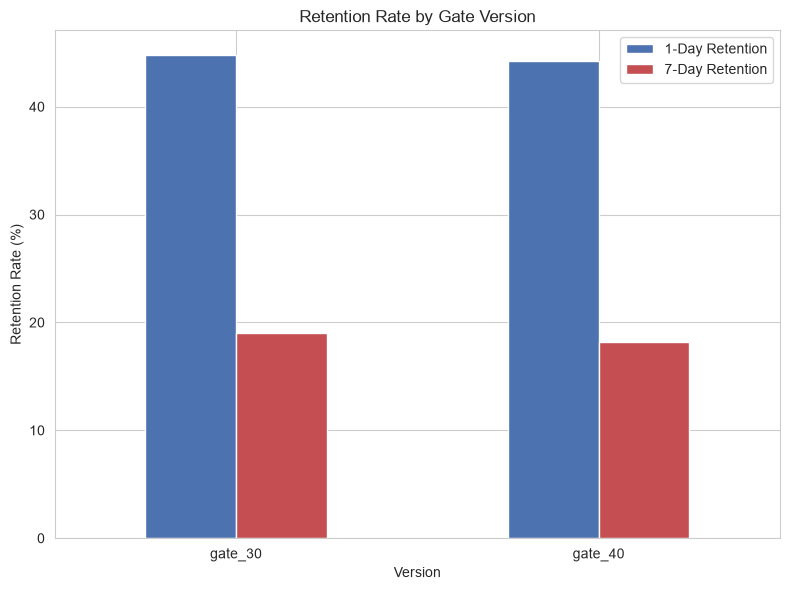

In [5]:
retention_rates = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100

retention_rates.plot(kind='bar', figsize=(8,6), color=['#4C72B0', '#C44E52'])
plt.title('Retention Rate by Gate Version')
plt.ylabel('Retention Rate (%)')
plt.xlabel('Version')
plt.xticks(rotation=0)
plt.legend(['1-Day Retention', '7-Day Retention'])
plt.tight_layout()
plt.show()

## Step 6: Bonus — Does Gate Placement Affect Engagement?
Beyond retention, let's check if players in either group played meaningfully more or 
fewer game rounds — this tells us if the gate change affects overall engagement, not 
just whether players return.

In [6]:
avg_rounds = df.groupby('version')['sum_gamerounds'].mean()
print(avg_rounds)

version
gate_30    52.456264
gate_40    51.298776
Name: sum_gamerounds, dtype: float64


## Conclusion

**Hypothesis:** Moving the first gate from level 30 to level 40 affects player retention.

**Results:**
- **1-Day Retention:** No statistically significant difference between gate_30 and gate_40 (p = 0.0755)
- **7-Day Retention:** Statistically significant difference found (p = 0.0016) — gate_30 (19.0%) retains 
  slightly more players than gate_40 (18.2%)

**Recommendation:** Keep the gate at level 30. While the change to level 40 shows no meaningful effect 
on short-term (1-day) retention, it appears to slightly hurt long-term (7-day) retention. Since retention 
is a key driver of long-term revenue in mobile games, this small but statistically significant decline is 
enough to recommend against making the change.